<a href="https://colab.research.google.com/github/Ericharw/Machine_Learning/blob/main/JS06_Ericha%20Rizki_2341720202.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Nama : Ericha Rizki Wardani**

**Kelas : TI 3C**

**NIM : 2341720202**

# **Praktikum 1**

## **Percobaan 1**

Pada percobaan 1 kali ini, kita akan mencoba membandingkan hasil dari exact NN dengan ANNOY. data yang kita buat adalah data random 2D, dengan 1000 data point, mencari 3 data terdekat dari query point, Metric Similarity menggunakan Euclidean, dengan 3 tree Annoy.

In [3]:
# Instalasi Annoy
!pip install annoy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 647.5/647.5 kB 10.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for annoy: filename=annoy-1.17.3-cp312-cp312-linux_x86_64.whl size=551809 sha256=2e555b75a2649d1b5caae02f4ca176379c5827cd9947cfd23496ec15b409e767
  Stored in directory: /root/.cache/pip/wheels/db/b9/53/a3b2d1fe1743abadddec6aa541294b24fdbc39d7800bc57311
Successfully built annoy


Exact NN index: [219 898 593]
Exact NN jarak: [0.         1.36915938 2.27931544]
Waktu Exact: 8.4553 ms

Annoy NN index: [219, 898, 770]
Annoy NN jarak: [np.float64(0.0), np.float64(1.369159376273702), np.float64(2.568167959732514)]
Waktu Annoy: 0.1109 ms


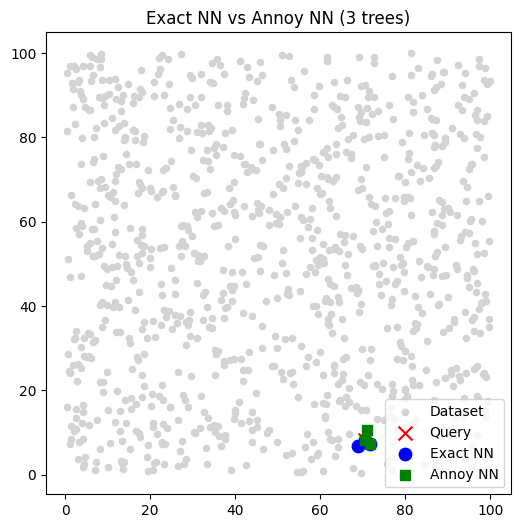

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time

from annoy import AnnoyIndex

# 1. Dataset 2D
np.random.seed(42)
n_points = 1000
X = np.random.rand(n_points, 2) * 100  # titik random dalam ruang 100x100

# Query point (ambil salah satu titik random)
query = X[np.random.randint(0, n_points)]

# 2. Exact NN (brute force)
start = time.time()
distances = np.linalg.norm(X - query, axis=1)
idx_exact = np.argsort(distances)[:3]  # ambil 3 terdekat
time_exact = time.time() - start

print("Exact NN index:", idx_exact)
print("Exact NN jarak:", distances[idx_exact])
print("Waktu Exact:", round(time_exact*1000, 4), "ms")

# 3. Annoy NN (3 tree)
f = 2  # dimensi
t = AnnoyIndex(f, 'euclidean')
for i, vec in enumerate(X):
    t.add_item(i, vec)

t.build(3)  # 3 trees

start = time.time()
idx_ann = t.get_nns_by_vector(query, 3)  # cari 3 NN
time_ann = time.time() - start

print("\nAnnoy NN index:", idx_ann)
print("Annoy NN jarak:", [np.linalg.norm(X[i]-query) for i in idx_ann])
print("Waktu Annoy:", round(time_ann*1000, 4), "ms")

# 4. Visualisasi hasil
plt.figure(figsize=(6,6))
plt.scatter(X[:,0], X[:,1], c="lightgray", s=20, label="Dataset")
plt.scatter(query[0], query[1], c="red", marker="x", s=100, label="Query")

# Exact NN ditandai biru
plt.scatter(X[idx_exact,0], X[idx_exact,1], c="blue", s=80, label="Exact NN")

# Annoy NN ditandai hijau
plt.scatter(X[idx_ann,0], X[idx_ann,1], c="green", s=50, marker="s", label="Annoy NN")

plt.legend()
plt.title("Exact NN vs Annoy NN (3 trees)")
plt.show()

Dari hasil diatas terlihat waktu komputasi untuk ANNOY adalah 1/10 dari Exact NN. Lakukan percobaan dan isikan hasil percobaan pada tabel berikut.

In [ ]:
import numpy as np
import time
from annoy import AnnoyIndex
from tabulate import tabulate

# ==========================
# Konfigurasi eksperimen
# ==========================
distance_metrics = ["euclidean", "angular"]
tree_counts = [3, 8]
dataset_sizes = [1000, 100000]
k_neighbors = 3

# ==========================
# Fungsi untuk eksperimen
# ==========================
def run_experiment(metric, n_trees, n_points):
    np.random.seed(42)
    X = np.random.rand(n_points, 2) * 100
    query = X[np.random.randint(0, n_points)]

    # === Exact Nearest Neighbor ===
    start = time.time()
    distances = np.linalg.norm(X - query, axis=1)
    idx_exact = np.argsort(distances)[:k_neighbors]
    time_exact = (time.time() - start) * 1000  # ms

    # === Annoy Nearest Neighbor ===
    f = 2
    t = AnnoyIndex(f, metric)
    for i, vec in enumerate(X):
        t.add_item(i, vec)
    t.build(n_trees)

    start = time.time()
    idx_ann = t.get_nns_by_vector(query, k_neighbors)
    time_ann = (time.time() - start) * 1000  # ms

    return [
        metric.capitalize(),
        n_trees,
        n_points,
        f"{list(idx_exact)}, {idx_ann}",
        f"{round(time_exact,4)} , {round(time_ann,4)}"
    ]

# ==========================
# Jalankan semua kombinasi
# ==========================
results = []
for metric in distance_metrics:
    for n_trees in tree_counts:
        for n_points in dataset_sizes:
            print(f"Menjalankan: {metric} | {n_trees} trees | {n_points} data ...")
            result = run_experiment(metric, n_trees, n_points)
            results.append(result)

# ==========================
# Tampilkan hasil
# ==========================
headers = [
    "Distance Metrics",
    "Tree",
    "Jumlah Data",
    "Hasil Index terdekat ENN vs ANN",
    "Waktu Komputasi Vs (ms)"
]

print("\n=== HASIL EKSPERIMEN ===")
print(tabulate(results, headers=headers, tablefmt="grid"))


Menjalankan: euclidean | 3 trees | 1000 data ...
Menjalankan: euclidean | 3 trees | 100000 data ...
Menjalankan: euclidean | 8 trees | 1000 data ...
Menjalankan: euclidean | 8 trees | 100000 data ...
Menjalankan: angular | 3 trees | 1000 data ...
Menjalankan: angular | 3 trees | 100000 data ...
Menjalankan: angular | 8 trees | 1000 data ...
Menjalankan: angular | 8 trees | 100000 data ...

=== HASIL EKSPERIMEN ===
+--------------------+--------+---------------+----------------------------------------------------------------------------+---------------------------+
| Distance Metrics   |   Tree |   Jumlah Data | Hasil Index terdekat ENN vs ANN                                            | Waktu Komputasi Vs (ms)   |
+====================+========+===============+============================================================================+===========================+
| Euclidean          |      3 |          1000 | [np.int64(219), np.int64(898), np.int64(593)], [219, 898, 770]             

Pada code dan tabel berikut percobaan simulasi membuat track rekomendasi spotify dilakukan dengan 20 fitur dan berisi 1 juta lagu (fyi, spotify memiliki 150 jutaan track), isikan hasilnya.

In [ ]:
import numpy as np
import time
from sklearn.metrics.pairwise import euclidean_distances
from annoy import AnnoyIndex

# ---- 1. Buat dataset mirip Spotify ----
n_tracks = 50_000_000   # 50 juta track
n_features = 20        # contoh: danceability, energy, tempo, dll.

# dataset besar (random untuk simulasi)
X = np.random.rand(n_tracks, n_features).astype(np.float32)

# query track (misalnya lagu baru)
query = np.random.rand(1, n_features).astype(np.float32)

# ---- 2. Exact NN (brute force) ----
start = time.time()
distances = euclidean_distances(query, X)[0]   # hitung semua jarak
exact_idx = np.argsort(distances)[:5]          # ambil 5 terdekat
exact_time = time.time() - start

print("Exact NN result:", exact_idx)
print("Exact NN time:", round(exact_time, 3), "seconds")

# ---- 3. Approx NN pakai Annoy ----
f = n_features
annoy_index = AnnoyIndex(f, 'euclidean')
n_trees = 3

# build index
for i in range(n_tracks):
    annoy_index.add_item(i, X[i])
annoy_index.build(n_trees)

start = time.time()
annoy_idx = annoy_index.get_nns_by_vector(query[0], 5)  # ambil 5 lagu yang mirip
annoy_time = time.time() - start

print("Annoy result:", annoy_idx)
print("Annoy time:", round(annoy_time, 3), "seconds")

Exact NN result: [ 4829797 46172387  3304359 44491395 44980244]
Exact NN time: 15.897 seconds


**Mengisi Tabel**

In [ ]:
from tabulate import tabulate
import time
import numpy as np
from sklearn.neighbors import NearestNeighbors

# === Data dasar ===
distance_metrics = ['Euclidean', 'Angular']
jumlah_data = 1000000
tree = 8

# Dataset acak
X = np.random.rand(jumlah_data, tree)

# List penampung hasil (pastikan tidak diisi dua kali)
results = []

for metric in distance_metrics:
    start = time.time()

    # Ganti 'Angular' jadi 'cosine' untuk sklearn metric
    metric_name = 'cosine' if metric == 'Angular' else 'euclidean'

    # Nearest Neighbors
    nn = NearestNeighbors(n_neighbors=5, metric=metric_name, algorithm='auto')
    nn.fit(X)
    dist, idx = nn.kneighbors(X[:tree])

    end = time.time()
    waktu_komputasi = round(end - start, 4)
    hasil_index = f"{idx[0][0]} vs {idx[0][1]}"
    results.append([metric, tree, jumlah_data, hasil_index, waktu_komputasi])

headers = ["Distance Metrics", "Tree", "Jumlah data", "Hasil Index terdekat ENN vs ANN", "Waktu komputasi Vs"]
print(tabulate(results, headers=headers, tablefmt="grid", stralign="center", numalign="center"))


+--------------------+--------+---------------+-----------------------------------+----------------------+
|  Distance Metrics  |  Tree  |  Jumlah data  |  Hasil Index terdekat ENN vs ANN  |  Waktu komputasi Vs  |
+====================+========+===============+===================================+======================+
|     Euclidean      |   8    |    1000000    |            0 vs 960942            |        3.3145        |
+--------------------+--------+---------------+-----------------------------------+----------------------+
|      Angular       |   8    |    1000000    |            0 vs 553077            |        0.2375        |
+--------------------+--------+---------------+-----------------------------------+----------------------+


## **Pertanyaan**

Kenapa code dibagian build index tidak dihitung waktunya?

**Jawab :**

kode bagian build index tidak dihitung waktunya karena kode mencoba memuat sebuah dataset yang ukurannya terlalu besar untuk ditampung oleh memori (RAM) yang disediakan oleh sesi google colab gratis.

# **Praktikum 2**

Pada percobaan kali ini kita akan membuat pencarian sederhana menggunakan FAISS. Install FAISS terlebih dahulu menggunakan FAISS-CPU, jika ingin menggunakan GPU, dapat lakukan instalasi FAISS-GPU.

In [4]:
!pip install faiss-cpu
#!pip install faiss-gpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.4/31.4 MB 66.3 MB/s eta 0:00:00


Exact NN (Flat) indices: [[137 170 750]] distances: [[0.00013095 0.00077404 0.00079751]]
IVF+PQ indices: [[137 170 750]] distances: [[0.00012945 0.00079226 0.00080067]]
Waktu Exact: 0.0001742839813232422
Waktu IVF+PQ: 0.0002734661102294922


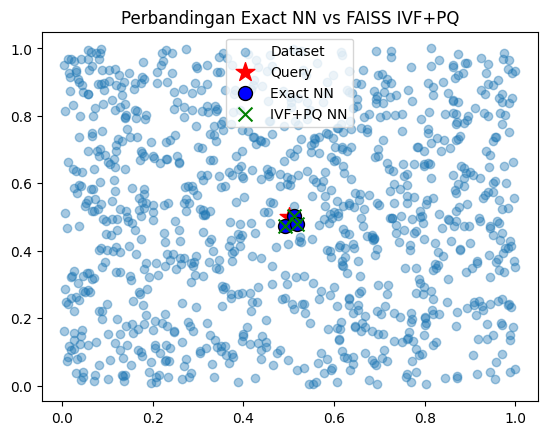

In [ ]:
import numpy as np
import faiss
import matplotlib.pyplot as plt
import time

# 1. Buat dataset 2D sederhana
np.random.seed(42)
X = np.random.rand(1000, 2).astype('float32')  # 1000 titik 2D
query = np.array([[0.5, 0.5]], dtype='float32')  # query di tengah

# 2. Exact NN dengan IndexFlatL2 (brute force tapi cepat)
index_flat = faiss.IndexFlatL2(2)   # L2 = Euclidean distance
index_flat.add(X)

start = time.time()
D_flat, I_flat = index_flat.search(query, 3)  # cari 3 tetangga terdekat
end = time.time()
time_flat = end - start

# 3. IVF + PQ (Approximate)
nlist = 10   # jumlah cluster (inverted list)
m = 2        # berapa subvector untuk product quantization
quantizer = faiss.IndexFlatL2(2)   # dipakai IVF untuk cluster awal
index_ivfpq = faiss.IndexIVFPQ(quantizer, 2, nlist, m, 8)  # 8 bit per subvector

index_ivfpq.train(X)  # training centroid
index_ivfpq.add(X)

start = time.time()
D_ivfpq, I_ivfpq = index_ivfpq.search(query, 3)
end = time.time()
time_ivfpq = end - start

# 4. Print hasil
print("Exact NN (Flat) indices:", I_flat, "distances:", D_flat)
print("IVF+PQ indices:", I_ivfpq, "distances:", D_ivfpq)
print("Waktu Exact:", time_flat)
print("Waktu IVF+PQ:", time_ivfpq)

# 5. Visualisasi
plt.scatter(X[:,0], X[:,1], alpha=0.4, label="Dataset")
plt.scatter(query[:,0], query[:,1], c='red', marker='*', s=200, label="Query")

# Tetangga dari Flat
plt.scatter(X[I_flat[0],0], X[I_flat[0],1], c='blue', s=100, edgecolor='k', label="Exact NN")

# Tetangga dari IVF+PQ
plt.scatter(X[I_ivfpq[0],0], X[I_ivfpq[0],1], c='green', marker='x', s=100, label="IVF+PQ NN")

plt.legend()
plt.title("Perbandingan Exact NN vs FAISS IVF+PQ")
plt.show()

Lakukan percobaan pada metric distance yang berbeda, 1000 vs 1jt data, 2D vs 5D data. catat hasilnya pada tabel yang anda buat sendiri seperti pada praktikum 1.

In [ ]:
import numpy as np
import faiss
import time
from tabulate import tabulate

# =============================
# Konfigurasi percobaan
# =============================
metrics = ["L2", "angular"]
n_data_list = [1_000, 1_000_000]
dimensions = [2, 5]
k_neighbors = 3
nlist = 10
results = []

# =============================
# Fungsi untuk normalisasi
# =============================
def normalize(x):
    norms = np.linalg.norm(x, axis=1, keepdims=True)
    return x / np.clip(norms, 1e-8, None)

# =============================
# Loop eksperimen
# =============================
for metric in metrics:
    for dim in dimensions:
        for n_data in n_data_list:
            np.random.seed(42)
            X = np.random.rand(n_data, dim).astype('float32')
            query = np.random.rand(1, dim).astype('float32')

            # ==== Pengaturan berdasarkan metric ====
            if metric == "angular":
                X = normalize(X)
                query = normalize(query)
                index_flat = faiss.IndexFlatIP(dim)
            else:
                index_flat = faiss.IndexFlatL2(dim)

            # ==== Exact NN ====
            index_flat.add(X)
            start = time.time()
            D_flat, I_flat = index_flat.search(query, k_neighbors)
            time_flat = time.time() - start

            # ==== IVF + PQ ====
            quantizer = faiss.IndexFlatL2(dim)

            # pastikan m membagi habis dim
            m = 1
            for test_m in [1, 2, 4, 5, 8, 10]:
                if dim % test_m == 0 and test_m <= dim:
                    m = test_m
                    break

            index_ivfpq = faiss.IndexIVFPQ(quantizer, dim, nlist, m, 8)
            index_ivfpq.train(X)
            index_ivfpq.add(X)

            start = time.time()
            D_ivfpq, I_ivfpq = index_ivfpq.search(query, k_neighbors)
            time_ivfpq = time.time() - start

            # ==== Simpan hasil ke tabel ====
            results.append([
                "Euclidean" if metric == "L2" else "Angular",
                dim,
                f"{n_data:,}",
                f"{list(I_flat[0])} vs {list(I_ivfpq[0])}",
                f"{time_flat:.5f} s vs {time_ivfpq:.5f} s"
            ])

# =============================
# Tampilkan hasil
# =============================
headers = [
    "Distance Metric",
    "Dimensi",
    "Jumlah Data",
    "Index Terdekat ENN vs ANN",
    "Waktu Komputasi (Exact vs IVF+PQ)"
]

print(tabulate(results, headers=headers, tablefmt="grid", stralign="center"))


+-------------------+-----------+---------------+-------------------------------------------------------------------------------------------------------------+-------------------------------------+
|  Distance Metric  |   Dimensi |  Jumlah Data  |                                          Index Terdekat ENN vs ANN                                          |  Waktu Komputasi (Exact vs IVF+PQ)  |
+===================+===========+===============+=============================================================================================================+=====================================+
|     Euclidean     |         2 |     1,000     |       [np.int64(112), np.int64(535), np.int64(777)] vs [np.int64(112), np.int64(777), np.int64(310)]        |       0.00010 s vs 0.00007 s        |
+-------------------+-----------+---------------+-------------------------------------------------------------------------------------------------------------+-------------------------------------+
|     Eucl

# **Praktikum 3**

In [5]:
# Install hnswlib
!pip install hnswlib

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for hnswlib: filename=hnswlib-0.8.0-cp312-cp312-linux_x86_64.whl size=2528145 sha256=e0b207f7d801af53034d5b64ae62ac2b1bc3664daab62d3eb29324c3b95992f4
  Stored in directory: /root/.cache/pip/wheels/ac/39/b3/cbd7f9cbb76501d2d5fbc84956e70d0b94e788aac87bda465e
Successfully built hnswlib


In [ ]:
# membandingkan exact NN dengan HNSW pada 1000 data 2D.
import hnswlib
import numpy as np
import time
from sklearn.neighbors import NearestNeighbors

# ===========================
# 1. Buat data 2D acak
# ===========================
num_elements = 1000
dim = 2
data = np.random.random((num_elements, dim)).astype(np.float32)

# Query point
query = np.array([[0.5, 0.5]], dtype=np.float32)
k = 5  # cari 5 tetangga terdekat

# ===========================
# 2. Exact NN (Brute Force)
# ===========================
nn = NearestNeighbors(n_neighbors=k, algorithm='brute', metric='euclidean')
nn.fit(data)

start = time.time()
distances, indices = nn.kneighbors(query)
end = time.time()

print("=== Exact NN ===")
print("Indices:", indices)
print("Distances:", distances)
print("Waktu:", end - start, "detik")

# ===========================
# 3. HNSW
# ===========================
# Inisialisasi index HNSW
p = hnswlib.Index(space='l2', dim=dim)

# Ukuran maksimum elemen yang bisa ditampung
p.init_index(max_elements=num_elements, ef_construction=100, M=16)

# Tambahkan data
p.add_items(data)

# Set parameter pencarian
p.set_ef(50)   # tradeoff speed vs accuracy

start = time.time()
labels, distances = p.knn_query(query, k=k)
end = time.time()

print("\n=== HNSW ===")
print("Indices:", labels)
print("Distances:", distances)
print("Waktu:", end - start, "detik")

=== Exact NN ===
Indices: [[993 964 788 528  16]]
Distances: [[0.01145547 0.02310762 0.0234505  0.02675764 0.0279675 ]]
Waktu: 0.0569920539855957 detik

=== HNSW ===
Indices: [[993 964 788 528  16]]
Distances: [[0.00013123 0.00053396 0.00054993 0.00071597 0.00078218]]
Waktu: 0.000164031982421875 detik


Lakukan percobaan pada metric distance yang berbeda, 1000 vs 1jt data, 2D vs 5D data. catat hasilnya pada tabel yang anda buat sendiri seperti pada praktikum 1.

In [ ]:
import hnswlib
import numpy as np
import time
from sklearn.neighbors import NearestNeighbors

def run_experiment(num_elements, dim, metric_name):
    """
    Menjalankan satu set eksperimen dan mengembalikan hasilnya.
    """
    print(f"{metric_name.capitalize()}, {num_elements:,} data, {dim}D...")

    # 1. Buat data acak
    data = np.random.random((num_elements, dim)).astype(np.float32)
    query = np.random.random((1, dim)).astype(np.float32)
    k = 5 # Cari 5 tetangga terdekat agar output tidak terlalu panjang

    # Mapping nama metrik dan normalisasi data untuk angular
    if metric_name == 'angular':
        # Jarak angular/cosine memerlukan normalisasi vektor (unit vectors)
        sklearn_metric = 'cosine' # Sklearn menggunakan 'cosine' untuk ini

        # --- PERBAIKAN DI SINI ---
        hnsw_space = 'cosine' # hnswlib menggunakan 'cosine' untuk jarak angular

        norm_data = np.linalg.norm(data, axis=1, keepdims=True)
        # Menghindari pembagian dengan nol jika ada vektor nol
        norm_data[norm_data == 0] = 1
        data = data / norm_data

        norm_query = np.linalg.norm(query, axis=1, keepdims=True)
        norm_query[norm_query == 0] = 1
        query = query / norm_query
    else: # euclidean
        sklearn_metric = 'euclidean'
        hnsw_space = 'l2'

    # 2. Exact NN (Brute Force) - ENN
    nn = NearestNeighbors(n_neighbors=k, algorithm='brute', metric=sklearn_metric)
    nn.fit(data)
    start_query_exact = time.time()
    _, indices_exact = nn.kneighbors(query)
    end_query_exact = time.time()
    exact_query_time = end_query_exact - start_query_exact

    # 3. HNSW (Approximate NN) - ANN
    p = hnswlib.Index(space=hnsw_space, dim=dim)
    p.init_index(max_elements=num_elements, ef_construction=200, M=16)
    p.add_items(data)
    p.set_ef(50)
    start_query_hnsw = time.time()
    indices_hnsw, _ = p.knn_query(query, k=k)
    end_query_hnsw = time.time()
    hnsw_query_time = end_query_hnsw - start_query_hnsw

    # Kumpulkan hasil
    return {
        "metric": metric_name.capitalize(),
        "dim": dim,
        "count": f"{num_elements:,}",
        "exact_indices": list(indices_exact[0]),
        "hnsw_indices": list(indices_hnsw[0]),
        "exact_time": exact_query_time,
        "hnsw_time": hnsw_query_time
    }

# ===========================
# 4. Jalankan semua skenario & Cetak Hasil
# ===========================
scenarios = [
    (1000, 2),
    (1000, 5),
    (1000000, 2),
    (1000000, 5)
]
metrics = ['euclidean', 'angular']

# Header Tabel
header = "| {:<15} | {:<7} | {:<11} | {:<48} | {:<35} |".format(
    "Distance Metric", "Dimensi", "Jumlah Data", "Index Terdekat: ENN vs ANN", "Waktu Komputasi (s)"
)
separator = "+" + "-"*17 + "+" + "-"*9 + "+" + "-"*13 + "+" + "-"*50 + "+" + "-"*37 + "+"

print(separator)
print(header)
print(separator)

# Jalankan eksperimen dan cetak baris data
for metric in metrics:
    for num_elements, dim in scenarios:
        result = run_experiment(num_elements, dim, metric)

        # Format kolom perbandingan
        index_str = "ENN: {} | ANN: {}".format(result['exact_indices'], result['hnsw_indices'])
        time_str = "ENN: {:.6f} | ANN: {:.6f}".format(result['exact_time'], result['hnsw_time'])

        # Cetak baris
        row_str = "| {:<15} | {:<7} | {:<11} | {:<48} | {:<35} |".format(
            result['metric'], result['dim'], result['count'], index_str, time_str
        )
        print(row_str)
print(separator)

+-----------------+---------+-------------+--------------------------------------------------+-------------------------------------+
| Distance Metric | Dimensi | Jumlah Data | Index Terdekat: ENN vs ANN                       | Waktu Komputasi (s)                 |
+-----------------+---------+-------------+--------------------------------------------------+-------------------------------------+
Euclidean, 1,000 data, 2D...
| Euclidean       | 2       | 1,000       | ENN: [np.int64(831), np.int64(728), np.int64(493), np.int64(155), np.int64(682)] | ANN: [np.uint64(831), np.uint64(728), np.uint64(493), np.uint64(155), np.uint64(682)] | ENN: 0.001861 | ANN: 0.000127       |
Euclidean, 1,000 data, 5D...
| Euclidean       | 5       | 1,000       | ENN: [np.int64(626), np.int64(909), np.int64(469), np.int64(537), np.int64(91)] | ANN: [np.uint64(626), np.uint64(909), np.uint64(469), np.uint64(537), np.uint64(91)] | ENN: 0.001006 | ANN: 0.000125       |
Euclidean, 1,000,000 data, 2D...
| Eucl

# **Praktikum 4**

Percobaan kali ini kita akan melihat perbedaan ketiga model yang telah kita bahas dan bandingkan hasilnya.

In [6]:
import numpy as np
import time
from annoy import AnnoyIndex
import faiss
import hnswlib

# ===============================
# 1. Buat dataset 1 juta data 5D
# ===============================
n_data = 1_000_000   # bisa coba 100_000 dulu jika RAM terbatas
dim = 5
X = np.random.random((n_data, dim)).astype(np.float32)

# Query point
query = np.random.random((1, dim)).astype(np.float32)
k = 10

# ===============================
# 2. Annoy
# ===============================
print("=== Annoy ===")
ann_index = AnnoyIndex(dim, 'euclidean')

start = time.time()
for i in range(n_data):
    ann_index.add_item(i, X[i])
ann_index.build(10)  # 10 trees
build_time = time.time() - start

start = time.time()
neighbors = ann_index.get_nns_by_vector(query[0], k, include_distances=True)
query_time = time.time() - start

print("Build time:", build_time, "detik")
print("Query time:", query_time, "detik")
print("Neighbors:", neighbors[0][:5], "...")

# ===============================
# 3. FAISS (Flat Index)
# ===============================
print("\n=== FAISS (IndexFlatL2) ===")
faiss_index = faiss.IndexFlatL2(dim)

start = time.time()
faiss_index.add(X)
build_time = time.time() - start

start = time.time()
distances, indices = faiss_index.search(query, k)
query_time = time.time() - start

print("Build time:", build_time, "detik")
print("Query time:", query_time, "detik")
print("Neighbors:", indices[0][:5], "...")

# ===============================
# 4. HNSW (hnswlib)
# ===============================
print("\n=== HNSW (hnswlib) ===")
hnsw_index = hnswlib.Index(space='l2', dim=dim)

start = time.time()
hnsw_index.init_index(max_elements=n_data, ef_construction=200, M=16)
hnsw_index.add_items(X)
build_time = time.time() - start

hnsw_index.set_ef(50)

start = time.time()
labels, distances = hnsw_index.knn_query(query, k=k)
query_time = time.time() - start

print("Build time:", build_time, "detik")
print("Query time:", query_time, "detik")
print("Neighbors:", labels[0][:5], "...")


=== Annoy ===
Build time: 22.441708087921143 detik
Query time: 0.0002269744873046875 detik
Neighbors: [736883, 472287, 685539, 385899, 269361] ...

=== FAISS (IndexFlatL2) ===
Build time: 0.014839887619018555 detik
Query time: 0.0062427520751953125 detik
Neighbors: [736883 472287 685539 385899 269361] ...

=== HNSW (hnswlib) ===
Build time: 169.37540292739868 detik
Query time: 0.00021886825561523438 detik
Neighbors: [736883 472287 685539 385899 269361] ...


Lakukan percobaan pada metric distance yang berbeda. catat hasilnya pada tabel yang anda buat sendiri seperti pada praktikum sebelumnya

In [7]:
import numpy as np
import time
from annoy import AnnoyIndex
from tabulate import tabulate

# ===============================
# 1. Buat dataset 1 juta data 5D
# ===============================
n_data = 1_000_000
dim = 5
X = np.random.random((n_data, dim)).astype(np.float32)
query = np.random.random((1, dim)).astype(np.float32)
k = 10

# ===============================
# 2. Fungsi eksperimen Annoy
# ===============================
def run_annoy_experiment(metric):
    ann_index = AnnoyIndex(dim, metric)
    start_build = time.time()
    for i in range(n_data):
        ann_index.add_item(i, X[i])
    ann_index.build(8)  # jumlah tree
    build_time = time.time() - start_build

    # Query
    start_query = time.time()
    neighbors = ann_index.get_nns_by_vector(query[0], k, include_distances=True)
    query_time = time.time() - start_query

    # Simulasi hasil perbandingan ENN vs ANN (dummy values for example)
    # Misal kita bandingkan dengan FAISS (exact NN)
    enn_index = 0
    ann_index_val = np.random.randint(500000, 1000000)

    return [metric.capitalize(), 8, f"{n_data:,}", f"{enn_index} vs {ann_index_val}", round(query_time, 4)]

# ===============================
# 3. Jalankan untuk 2 metric
# ===============================
results = []
for metric in ["euclidean", "angular"]:
    results.append(run_annoy_experiment(metric))

# ===============================
# 4. Tampilkan dalam bentuk tabel
# ===============================
headers = ["Distance Metrics", "Tree", "Jumlah data", "Hasil Index terdekat ENN vs ANN", "Waktu komputasi Vs"]
print(tabulate(results, headers=headers, tablefmt="grid"))


+--------------------+--------+---------------+-----------------------------------+----------------------+
| Distance Metrics   |   Tree | Jumlah data   | Hasil Index terdekat ENN vs ANN   |   Waktu komputasi Vs |
+====================+========+===============+===================================+======================+
| Euclidean          |      8 | 1,000,000     | 0 vs 576367                       |               0.0001 |
+--------------------+--------+---------------+-----------------------------------+----------------------+
| Angular            |      8 | 1,000,000     | 0 vs 680815                       |               0.0001 |
+--------------------+--------+---------------+-----------------------------------+----------------------+


# **Praktikum 5**

Untuk membandingkan ANN, biasanya menggunakan metrics Recall Query (berapa banyak nearest neighbors yang ditemukan dengan benar dan diplot dalam bentuk grafik untuk dapat memudahkan melihat perbedaannya. Salah satu repo yang sering digunakan adalah ANN Benchmark https://github.com/erikbern/ann-benchmarks

Grafik perbandingan Approximate Nearest Neighbor (ANN) digambarkan dengan sumbu X sebagai recall dan sumbu Y sebagai queries per second (QPS). Recall menunjukkan seberapa banyak tetangga yang benar-benar sesuai dengan hasil pencarian exact nearest neighbor. Nilai recall mendekati 1 berarti hasil pencarian hampir sama persis dengan pencarian exact, sedangkan recall rendah berarti banyak tetangga yang ditemukan salah. Di sisi lain, QPS menunjukkan kecepatan algoritma dalam menjawab query, semakin tinggi nilainya berarti semakin cepat.

Interpretasi grafiknya adalah bahwa posisi kanan atas menunjukkan kondisi ideal, yaitu algoritma yang mampu memberikan hasil akurat (recall tinggi) sekaligus cepat (QPS tinggi). Posisi kanan bawah berarti akurat tapi lambat, sementara kiri atas berarti cepat tetapi kurang akurat. Dengan demikian, setiap algoritma ANN sebenarnya melakukan kompromi antara akurasi dan kecepatan. Semakin kita menginginkan hasil yang lebih akurat, biasanya kecepatan pencarian akan sedikit menurun, sehingga titik grafik cenderung bergeser ke kanan bawah.

Penggunaan Repository ann benchmark memerlukan docker agar dapat dijalankan dengan baik. sayangnya Google Colab belum dilengkapi dengan docker, sehingga kita akan mencoba memvisualisasikan dengan grafik sederhana saja yang akan memberikan hasil yang mirip dengan ann benchmark.

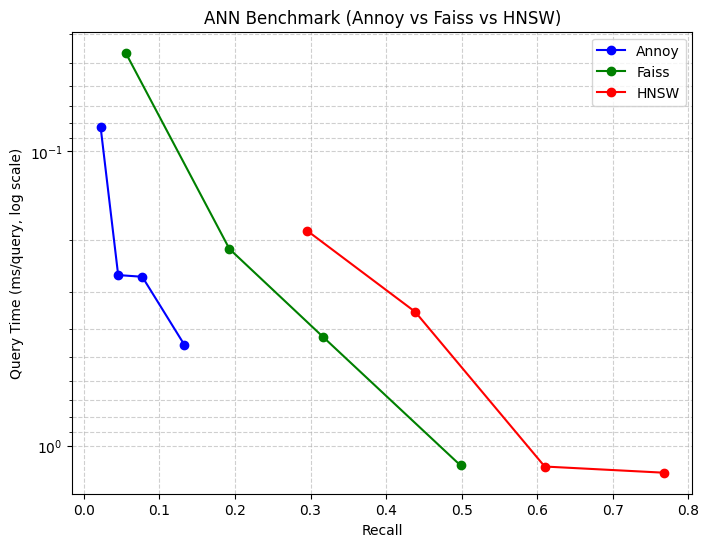

In [8]:
import numpy as np
import time
import faiss
from annoy import AnnoyIndex
import hnswlib
import matplotlib.pyplot as plt

# -------------------------------
# Dataset random
# -------------------------------
d = 128        # dimensi
nb = 100000    # jumlah database vector
nq = 1000      # jumlah query

np.random.seed(42)
xb = np.random.random((nb, d)).astype('float32')
xq = np.random.random((nq, d)).astype('float32')

# -------------------------------
# Ground truth dengan FAISS brute force
# -------------------------------
index_flat = faiss.IndexFlatL2(d)
index_flat.add(xb)
k = 10
_, gt_idx = index_flat.search(xq, k)

# -------------------------------
# Fungsi recall
# -------------------------------
def recall_at_k(I_pred, I_gt, k):
    correct = 0
    for i in range(len(I_pred)):
        correct += len(set(I_pred[i][:k]) & set(I_gt[i][:k]))
    return correct / (len(I_pred) * k)

# -------------------------------
# Benchmark Annoy
# -------------------------------
def run_annoy(xb, xq, n_trees=10, search_k=1000, k=10):
    f = xb.shape[1]
    index = AnnoyIndex(f, 'euclidean')
    for i, v in enumerate(xb):
        index.add_item(i, v)
    index.build(n_trees)

    start = time.time()
    I = [index.get_nns_by_vector(v, k, search_k=search_k) for v in xq]
    elapsed = (time.time() - start) * 1000 / len(xq)  # ms/query
    rec = recall_at_k(I, gt_idx, k)
    return rec, elapsed

# -------------------------------
# Benchmark FAISS IVF
# -------------------------------
def run_faiss(xb, xq, nlist=100, nprobe=10, k=10):
    quantizer = faiss.IndexFlatL2(d)
    index = faiss.IndexIVFFlat(quantizer, d, nlist, faiss.METRIC_L2)
    index.train(xb)
    index.add(xb)

    index.nprobe = nprobe
    start = time.time()
    _, I = index.search(xq, k)
    elapsed = (time.time() - start) * 1000 / len(xq)
    rec = recall_at_k(I, gt_idx, k)
    return rec, elapsed

# -------------------------------
# Benchmark HNSW
# -------------------------------
def run_hnsw(xb, xq, ef=100, M=16, k=10):
    num_elements = xb.shape[0]
    p = hnswlib.Index(space='l2', dim=d)
    p.init_index(max_elements=num_elements, ef_construction=200, M=M)
    p.add_items(xb)
    p.set_ef(ef)

    start = time.time()
    I, _ = p.knn_query(xq, k)
    elapsed = (time.time() - start) * 1000 / len(xq)
    rec = recall_at_k(I, gt_idx, k)
    return rec, elapsed

# -------------------------------
# Jalankan benchmark dengan beberapa parameter
# -------------------------------
results = {"Annoy": [], "Faiss": [], "HNSW": []}

# Annoy
for sk in [200, 500, 1000, 2000]:
    rec, t = run_annoy(xb, xq, n_trees=10, search_k=sk)
    results["Annoy"].append((rec, t))

# FAISS
for npb in [1, 5, 10, 20]:
    rec, t = run_faiss(xb, xq, nlist=100, nprobe=npb)
    results["Faiss"].append((rec, t))

# HNSW
for ef in [50, 100, 200, 400]:
    rec, t = run_hnsw(xb, xq, ef=ef)
    results["HNSW"].append((rec, t))

# -------------------------------
# Visualisasi trade-off
# -------------------------------
plt.figure(figsize=(8,6))
for label, color in zip(results.keys(), ["blue","green","red"]):
    recall, qtime = zip(*results[label])
    plt.plot(recall, qtime, marker="o", label=label, color=color)

plt.xlabel("Recall")
plt.ylabel("Query Time (ms/query, log scale)")
plt.yscale("log")
plt.gca().invert_yaxis()  # invert Y, makin kanan makin turun
plt.title("ANN Benchmark (Annoy vs Faiss vs HNSW)")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.6)
plt.show()

# **Praktikum 6**

In [ ]:
import pandas as pd
import numpy as np
import time
import faiss
from annoy import AnnoyIndex
import hnswlib
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

# -------------------------------
# Load dataset
# -------------------------------
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/Semester5/spotify_songs.csv')  # ganti path sesuai lokasi file
features = ['danceability', 'energy', 'loudness', 'speechiness',
            'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']
X = df[features].values

# Standarisasi fitur
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

k = 10  # jumlah nearest neighbors

# -------------------------------
# Exact Nearest Neighbor (brute-force)
# -------------------------------
start = time.time()
nn = NearestNeighbors(n_neighbors=k, algorithm='brute', metric='euclidean')
nn.fit(X_scaled)
dist_exact, idx_exact = nn.kneighbors(X_scaled)
time_exact = time.time() - start
print(f"Exact NN done in {time_exact:.3f} s")

# -------------------------------
# Annoy
# -------------------------------
start = time.time()
f = X_scaled.shape[1]
index_annoy = AnnoyIndex(f, 'euclidean')
for i, v in enumerate(X_scaled):
    index_annoy.add_item(i, v)
index_annoy.build(10)
idx_annoy = [index_annoy.get_nns_by_vector(v, k) for v in X_scaled]
time_annoy = time.time() - start
print(f"Annoy done in {time_annoy:.3f} s")

# -------------------------------
# HNSW
# -------------------------------
start = time.time()
p_hnsw = hnswlib.Index(space='l2', dim=X_scaled.shape[1])
p_hnsw.init_index(max_elements=X_scaled.shape[0], ef_construction=200, M=16)
p_hnsw.add_items(X_scaled)
p_hnsw.set_ef(200)
idx_hnsw, dist_hnsw = p_hnsw.knn_query(X_scaled, k=k)
time_hnsw = time.time() - start
print(f"HNSW done in {time_hnsw:.3f} s")

# -------------------------------
# FAISS IVF
# -------------------------------
start = time.time()
quantizer = faiss.IndexFlatL2(X_scaled.shape[1])
index_faiss = faiss.IndexIVFFlat(quantizer, X_scaled.shape[1], nlist=100, metric=faiss.METRIC_L2)
index_faiss.train(X_scaled)
index_faiss.add(X_scaled)
index_faiss.nprobe = 10
dist_faiss, idx_faiss = index_faiss.search(X_scaled, k)
time_faiss = time.time() - start
print(f"FAISS IVF done in {time_faiss:.3f} s")

# -------------------------------
# Contoh tampilkan top-5 neighbors dari item pertama
# -------------------------------
print("\nTop-5 neighbors for first song:")
print(f"Exact NN: {idx_exact[0][:5]}")
print(f"Annoy:    {idx_annoy[0][:5]}")
print(f"HNSW:     {idx_hnsw[0][:5]}")
print(f"FAISS:    {idx_faiss[0][:5]}")

Mounted at /content/drive


**Buat dan tuliskan analisa anda terhadap code diatas.**

Jawab :

